# Modelo Preditivo
### Grupo:
* Gabriel Koji Kondo;
* João Vitor Vargas Pereira;
* Rafael Barreto da Cruz;
* Raissa Arruda Casale;
* Ryan Lionel de Souza.

O objetivo deste notebook é prever o próximo título a ser assitido por um usuário da Netflix, baseado em informações sobre o conteúdo consumido pela conta

## 0. Importações

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
from sklearn.inspection import permutation_importance


%matplotlib inline

## 1. Carregamento de dados

In [ ]:
df_api = pd.read_csv('../dados-transformados/tmdb_completo.csv')
df_viewing = pd.read_csv('../dados-transformados/ViewingActivityCorrigido.csv')

df_viewing[['Title', 'Temporada', 'Episodio']] = df_viewing['Title'].str.split(': ', n=2, expand=True)

df_viewing["Title"] = df_viewing["Title"].str.replace(r"\(.*?\)", "", regex=True).str.strip()

df = df_viewing.merge(df_api, left_on="Title", right_on="Tittle_Name", how="left")

## 2. Pré Processamento

In [ ]:
df["Start Time"] = pd.to_datetime(df["Start Time"], errors="coerce")
df = df.sort_values(["Profile Name", "Start Time"])

df["genero_anterior"] = df.groupby("Profile Name")["genres"].shift(1)
df["genero_atual"] = df["genres"]
df["proximo_genero"] = df.groupby("Profile Name")["genres"].shift(-1)

df = df.dropna(subset=["proximo_genero"])

df["dia_semana"] = df["Start Time"].dt.dayofweek
df["hora"] = df["Start Time"].dt.hour

dummies_atual = pd.get_dummies(df["genero_atual"], prefix="flag")
dummies_anterior = pd.get_dummies(df["genero_anterior"], prefix="lag") 

props = dummies_atual.groupby(df["Profile Name"]).transform("mean").add_prefix("prop_")

df = pd.concat([df, dummies_atual, dummies_anterior, props], axis=1)
df = df.loc[:, ~df.columns.duplicated()]

C:\Users\gabrielkondo-ieg\AppData\Local\Temp\ipykernel_1564\91843440.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Start Time"] = pd.to_datetime(df["Start Time"], errors="coerce")


In [ ]:
y_list = df["proximo_genero"].fillna("Desconhecido").str.split(", ")

mlb = MultiLabelBinarizer()
y_bin = mlb.fit_transform(y_list)

print(f"Número de gêneros únicos a prever: {len(mlb.classes_)}")

colunas_remover = [
    "proximo_genero", "Start Time", "Profile Name", "Title", "Tittle_Name",
    "genres", "genero_atual", "genero_anterior", "director", "director_list"
]

X = df.drop(columns=colunas_remover, errors="ignore")

X = X.select_dtypes(include=['int64', 'float64', 'uint8', 'int32', 'bool']).fillna(0)

Número de gêneros únicos a prever: 26


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

base_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model = ClassifierChain(base_rf, order='random', random_state=42)

print("Treinando o modelo... (Isso pode levar alguns segundos)")
model.fit(X_train, y_train)
print("Treinamento concluído!")

Treinando o modelo... (Isso pode levar alguns segundos)
Treinamento concluído!


## 3. Separação entre treino e teste

## 3.1 Separando os x e y

In [54]:
y_pred = model.predict(X_test)

print("--- Relatório de Classificação Multilabel ---")
print(classification_report(y_test, y_pred, target_names=mlb.classes_, zero_division=0))

--- Relatório de Classificação Multilabel ---
                    precision    recall  f1-score   support

Action & Adventure       0.90      0.24      0.38       373
          Animação       0.66      0.27      0.38       329
          Aventura       1.00      0.01      0.02       115
              Ação       0.87      0.15      0.26        85
         Cinema TV       0.00      0.00      0.00         1
           Comédia       0.79      0.33      0.47       774
             Crime       0.87      0.19      0.31       296
      Documentário       0.00      0.00      0.00        32
             Drama       0.74      0.89      0.81      1217
           Família       0.79      0.13      0.22       239
          Fantasia       1.00      0.03      0.05        37
          Faroeste       0.67      0.11      0.18        19
 Ficção científica       0.88      0.25      0.39        56
            Guerra       0.00      0.00      0.00         6
          História       0.00      0.00      0.00    

# Permutation Importance

In [58]:
print("Calculando Permutation Importance (versão otimizada)...")


X_test_amostra = X_test.iloc[:1000]
y_test_amostra = y_test[:1000]

result = permutation_importance(
    model, 
    X_test_amostra, 
    y_test_amostra, 
    n_repeats=3,      
    random_state=42, 
    n_jobs=-1         
)

df_perm_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importância': result.importances_mean,
    'Desvio_Padrao': result.importances_std
}).sort_values(by='Importância', ascending=True)

top_features = df_perm_importance.tail(15)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features['Feature'], 
    top_features['Importância'], 
    xerr=top_features['Desvio_Padrao'], 
    color='coral', 
    edgecolor='black',
    capsize=5, 
    alpha=0.9
)

plt.xlabel('Queda na Acurácia (Importância Média)')
plt.title('Top 15 Variáveis Mais Importantes (Permutation Importance)')

plt.grid(axis='x', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()

Calculando Permutation Importance (versão otimizada)...


KeyboardInterrupt: 

# SHAP

Calculando SHAP Values (isso pode demorar alguns segundos)...


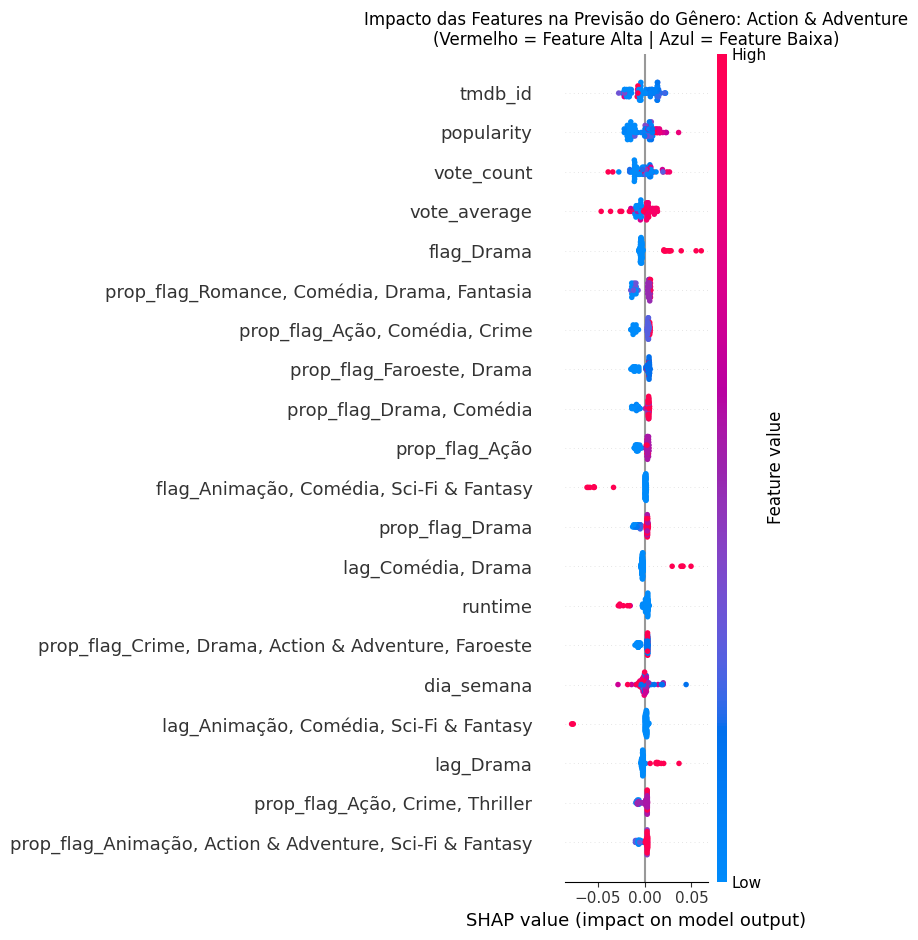

In [ ]:
print("Calculando SHAP Values (isso pode demorar alguns segundos)...")

X_amostra = X_test.iloc[:100, :]

explainer = shap.TreeExplainer(model.estimators_[0], feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X_amostra, check_additivity=False)

if isinstance(shap_values, list):
    shap_values_alvo = shap_values[1] 
else:
    if len(shap_values.shape) > 2:
        shap_values_alvo = shap_values[:, :, 1]
    else:
        shap_values_alvo = shap_values

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_alvo, 
    X_amostra, 
    plot_type="dot", 
    show=False
)

# Agora sim colocamos o título!
plt.title(f"Impacto das Features na Previsão do Gênero: {mlb.classes_[0]}\n(Vermelho = Feature Alta | Azul = Feature Baixa)")
plt.tight_layout()
plt.show()

# Previsões Finais (Baseadas por Usuário)

In [70]:
ultimas_atividades = X.loc[df.groupby("Profile Name")["Start Time"].idxmax()]

preds_binarias = model.predict(ultimas_atividades)

generos_previstos = mlb.inverse_transform(preds_binarias)

relatorio_usuarios = pd.DataFrame({
    'Usuario': df.groupby("Profile Name")["Profile Name"].first().values,
    'Ultimo_Genero_Visto': df.groupby("Profile Name")["genres"].last().values,
    'Previsao_Proxima_Sessao': [", ".join(g) if g else "Indefinido" for g in generos_previstos]
})

print("--- Sugestões para o Próximo Acesso ---")
display(relatorio_usuarios)


--- Sugestões para o Próximo Acesso ---


,Usuario,Ultimo_Genero_Visto,Previsao_Proxima_Sessao
0,Extra,Drama,Drama
1,João Vitor,"Animação, Action & Adventure, Drama, Sci-Fi & ...",Animação
2,Rafael,"Comédia, Drama",Indefinido
3,Raiss,"Sci-Fi & Fantasy, Drama, Mistério",Drama
4,Ryan,Drama,Indefinido
